# Coding Ninjas 10X – AI/ML Recruitment (First Years)
# Task 2: Linear Regression – Predicting MPG

**Goal:** build Linear Regression models to predict `mpg` from vehicle characteristics using the cleaned dataset from Task 1, evaluate them, and analyse strengths and limitations.

In [16]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import Markdown, display
sns.set_theme(style="whitegrid")

## Part A – Data Preparation

In [17]:
# Load the cleaned dataset produced by Task 1.
# The user must place "auto_mpg_cleaned.csv" in the same folder as this notebook.

try:
    df = pd.read_csv("auto_mpg_cleaned.csv")

    print("Loaded auto_mpg_cleaned.csv successfully")
    print("Shape:", df.shape)
    print("Missing values:", df.isna().sum().sum())
    print("Duplicates:", df.duplicated().sum())

except FileNotFoundError:
    print("ERROR: auto_mpg_cleaned.csv was not found.")
    print("Please place the cleaned dataset in the same folder as this notebook and run the cell again.")

Loaded auto_mpg_cleaned.csv successfully
Shape: (398, 10)
Missing values: 0
Duplicates: 0


In [18]:
# Target and features
y = df["mpg"]
X = df.drop(columns=["mpg", "car_name", "year_full"])   # remove car_name (identifier); year_full duplicates model_year

# One-hot encode origin. drop_first avoids the "dummy variable trap" (perfect collinearity)
X = pd.get_dummies(X, columns=["origin"], drop_first=True, dtype=int)
print("Features used:", list(X.columns))
X.head()

Features used: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,8,307.0,130.0,3504,12.0,70,0,1
1,8,350.0,165.0,3693,11.5,70,0,1
2,8,318.0,150.0,3436,11.0,70,0,1
3,8,304.0,150.0,3433,12.0,70,0,1
4,8,302.0,140.0,3449,10.5,70,0,1


`origin` is nominal (no natural order), so it is **one-hot encoded** – label-encoding 0/1/2 would wrongly imply an order. `europe` is the reference group (dropped); the coefficients of `origin_japan`/`origin_usa` are relative to Europe.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (318, 8)  Test: (80, 8)


## Part B – Linear Regression

In [20]:
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"MAE": mean_absolute_error(y_true, y_pred), "MSE": mse, "RMSE": np.sqrt(mse), "R2": r2_score(y_true, y_pred)}

### B1. Single-feature model: weight → MPG

MPG = 46.78 + (-0.00781) x weight
-> every extra 1000 lb changes MPG by -7.81


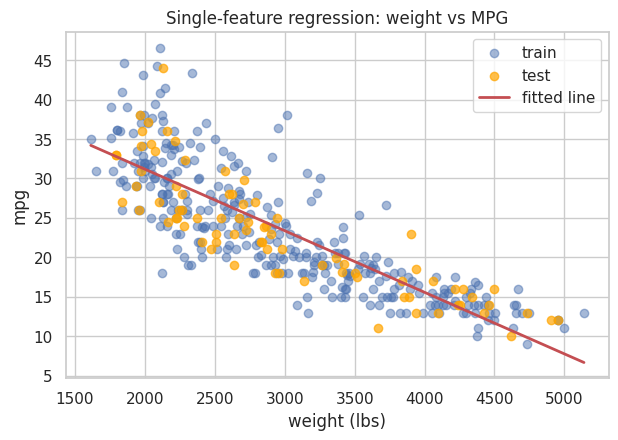

,MAE,MSE,RMSE,R2
Train,3.359294,19.781924,4.447687,0.684480
Test,3.117786,14.894861,3.859386,0.722971


In [21]:
m1 = LinearRegression().fit(X_train[["weight"]], y_train)
p1_tr, p1_te = m1.predict(X_train[["weight"]]), m1.predict(X_test[["weight"]])
print(f"MPG = {m1.intercept_:.2f} + ({m1.coef_[0]:.5f}) x weight")
print(f"-> every extra 1000 lb changes MPG by {m1.coef_[0]*1000:.2f}")

plt.figure(figsize=(7, 4.5))
plt.scatter(X_train.weight, y_train, alpha=.5, label="train")
plt.scatter(X_test.weight, y_test, alpha=.7, color="orange", label="test")
w = np.linspace(X.weight.min(), X.weight.max(), 100)
plt.plot(w, m1.predict(pd.DataFrame({"weight": w})), "r-", lw=2, label="fitted line")
plt.xlabel("weight (lbs)"); plt.ylabel("mpg"); plt.title("Single-feature regression: weight vs MPG"); plt.legend(); plt.show()

res1 = pd.DataFrame({"Train": evaluate(y_train, p1_tr), "Test": evaluate(y_test, p1_te)}).T
res1

### B2. Multiple linear regression (all relevant features)

In [22]:
m2 = LinearRegression().fit(X_train, y_train)
p2_tr, p2_te = m2.predict(X_train), m2.predict(X_test)

coefs = pd.Series(m2.coef_, index=X.columns).sort_values()
print("Intercept:", round(m2.intercept_, 3)); print(coefs.round(4))

res2 = pd.DataFrame({"Train": evaluate(y_train, p2_tr), "Test": evaluate(y_test, p2_te)}).T
res2

Intercept: -18.672
origin_usa     -2.9551
origin_japan   -0.2611
cylinders      -0.1667
horsepower     -0.0158
weight         -0.0070
displacement    0.0200
acceleration    0.0622
model_year      0.8242
dtype: float64


,MAE,MSE,RMSE,R2
Train,2.603493,11.350914,3.369112,0.818954
Test,2.284803,8.332436,2.886596,0.845025


In [23]:
comparison = pd.concat({"Simple (weight)": res1, "Multiple (all features)": res2}, axis=0)
comparison.round(3)

MAE     MSE   RMSE     R2
Simple (weight)         Train  3.359  19.782  4.448  0.684
                        Test   3.118  14.895  3.859  0.723
Multiple (all features) Train  2.603  11.351  3.369  0.819
                        Test   2.285   8.332  2.887  0.845

## Part C – Model Analysis

### C1. Actual vs Predicted (test data)

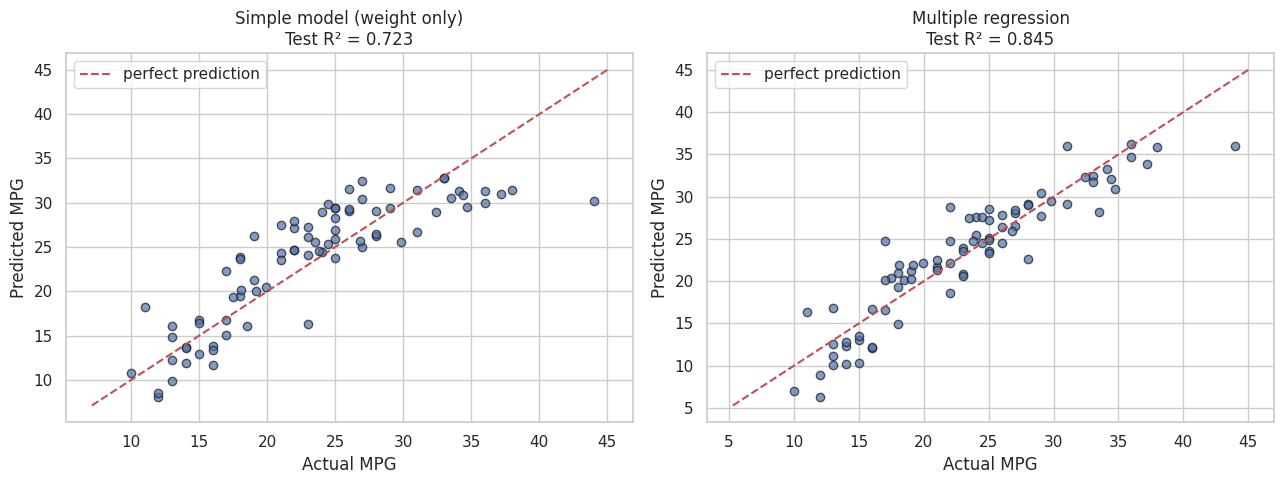

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, p, t in zip(ax, [p1_te, p2_te], ["Simple model (weight only)", "Multiple regression"]):
    a.scatter(y_test, p, alpha=.7, edgecolor="k")
    lim = [min(y_test.min(), p.min()) - 1, max(y_test.max(), p.max()) + 1]
    a.plot(lim, lim, "r--", label="perfect prediction")
    a.set_xlabel("Actual MPG"); a.set_ylabel("Predicted MPG")
    a.set_title(f"{t}\nTest R² = {r2_score(y_test, p):.3f}"); a.legend()
plt.tight_layout(); plt.show()

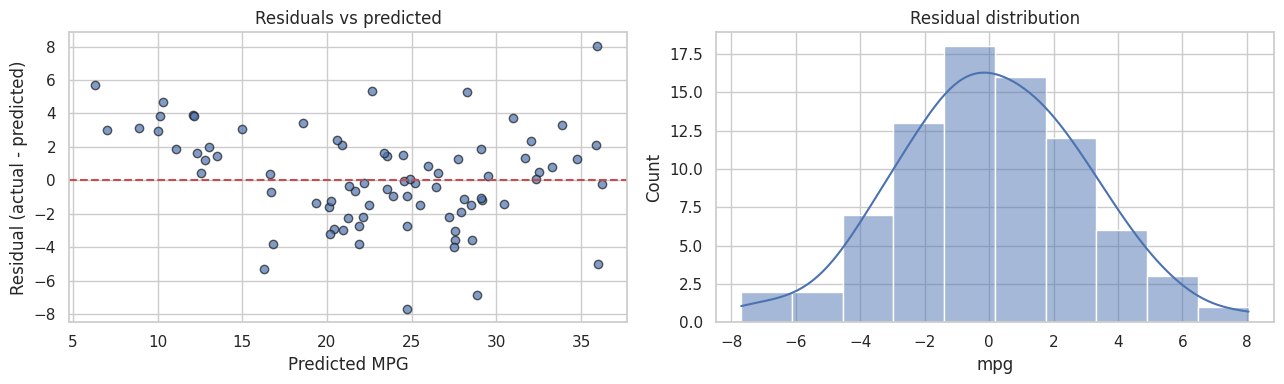

In [25]:
# Residual diagnostics for the multiple model
resid = y_test - p2_te
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(p2_te, resid, alpha=.7, edgecolor="k"); ax[0].axhline(0, color="r", ls="--")
ax[0].set_xlabel("Predicted MPG"); ax[0].set_ylabel("Residual (actual - predicted)"); ax[0].set_title("Residuals vs predicted")
sns.histplot(resid, kde=True, ax=ax[1]); ax[1].set_title("Residual distribution")
plt.tight_layout(); plt.show()

### C2. Training vs testing performance

In [26]:
gap = res2.loc["Train", "R2"] - res2.loc["Test", "R2"]
print(res2.round(3)); print(f"\nR² gap (train - test) = {gap:.3f}")
print(f"RMSE train = {res2.loc['Train','RMSE']:.2f}  vs  test = {res2.loc['Test','RMSE']:.2f}")

         MAE     MSE   RMSE     R2
Train  2.603  11.351  3.369  0.819
Test   2.285   8.332  2.887  0.845

R² gap (train - test) = -0.026
RMSE train = 3.37  vs  test = 2.89


In [27]:
train_r2, test_r2 = res2.loc["Train", "R2"], res2.loc["Test", "R2"]
display(Markdown(f'''
**Overfitting / underfitting:**
- Train R² = **{train_r2:.3f}**, test R² = **{test_r2:.3f}** – test performance is as good as (even slightly better than) training performance, and test RMSE is not higher than train RMSE. The slightly better test score is just a quirk of this particular 80/20 split (the test set happens to contain fewer hard cases). There is **no sign of overfitting** (expected: linear regression has low capacity and we have only 8 features for ~318 training rows).
- The model explains about {test_r2*100:.0f}% of MPG variance, which is good but not perfect. The residuals are not perfectly random: the model tends to over-predict in the middle of the MPG range and under-predict at the very high end, and errors are largest for the least efficient cars – a sign of **mild underfitting**, because a straight-line model cannot fully capture the curved MPG–weight relationship seen in the EDA.

**Interpreting the metrics (multiple model, test set):**
- **MAE = {res2.loc['Test','MAE']:.2f}** – on average predictions are about {res2.loc['Test','MAE']:.1f} mpg off.
- **MSE = {res2.loc['Test','MSE']:.2f}** – mean squared error in mpg² (penalises large errors heavily; hard to read directly).
- **RMSE = {res2.loc['Test','RMSE']:.2f}** – typical error size in mpg; slightly above MAE because it punishes big misses more.
- **R² = {test_r2:.3f}** – fraction of MPG variance explained by the model (1 = perfect, 0 = no better than predicting the mean). Weight alone gives R² = {res1.loc['Test','R2']:.3f}.
'''))


**Overfitting / underfitting:**
- Train R² = **0.819**, test R² = **0.845** – test performance is as good as (even slightly better than) training performance, and test RMSE is not higher than train RMSE. The slightly better test score is just a quirk of this particular 80/20 split (the test set happens to contain fewer hard cases). There is **no sign of overfitting** (expected: linear regression has low capacity and we have only 8 features for ~318 training rows).
- The model explains about 85% of MPG variance, which is good but not perfect. The residuals are not perfectly random: the model tends to over-predict in the middle of the MPG range and under-predict at the very high end, and errors are largest for the least efficient cars – a sign of **mild underfitting**, because a straight-line model cannot fully capture the curved MPG–weight relationship seen in the EDA.

**Interpreting the metrics (multiple model, test set):**
- **MAE = 2.28** – on average predictions are about 2.3 mpg off.
- **MSE = 8.33** – mean squared error in mpg² (penalises large errors heavily; hard to read directly).
- **RMSE = 2.89** – typical error size in mpg; slightly above MAE because it punishes big misses more.
- **R² = 0.845** – fraction of MPG variance explained by the model (1 = perfect, 0 = no better than predicting the mean). Weight alone gives R² = 0.723.


## Part D – Insights

In [28]:
extra = pd.Series(m2.coef_, index=X.columns)
display(Markdown(f'''
### Key findings
1. **Weight alone is a strong predictor:** the single-feature model reaches test R² = {res1.loc['Test','R2']:.2f} (RMSE {res1.loc['Test','RMSE']:.2f} mpg); each additional 1000 lb lowers MPG by ≈ {abs(m1.coef_[0]*1000):.1f}.
2. **Adding more features improves the model:** test R² rises from {res1.loc['Test','R2']:.2f} to {res2.loc['Test','R2']:.2f} and RMSE drops from {res1.loc['Test','RMSE']:.2f} to {res2.loc['Test','RMSE']:.2f} mpg.
3. **Model year has a positive effect:** holding other features fixed, each year adds ≈ {extra['model_year']:.2f} mpg (technology and regulation improvements).
4. **Weight remains the dominant negative driver** in the multiple model (coef ≈ {extra['weight']*1000:.1f} mpg per 1000 lb) while the other engine variables have small or unstable coefficients because they are correlated with weight.
5. **Good generalisation:** train and test scores are close (R² {train_r2:.2f} vs {test_r2:.2f}); no sign of overfitting.
6. **Typical error is ≈ {res2.loc['Test','MAE']:.1f} mpg (MAE)**, with larger errors for the least efficient cars and a systematic (curved) residual pattern.

### Limitations of Linear Regression for this dataset
1. **Non-linearity:** MPG vs weight/horsepower is curved (diminishing returns), but a linear model fits straight lines – hence the residual pattern.
2. **Multicollinearity:** displacement, horsepower, cylinders and weight are highly correlated, so individual coefficients are unstable and hard to interpret (some signs are counter-intuitive).
3. **Small dataset (~400 rows) & one 80/20 split:** results can vary with the split; rare groups (3- and 5-cylinder cars) are barely represented.
4. **Sensitive to outliers / non-constant variance:** errors are larger for low-MPG (gas-guzzler) cars, which partly violates the constant-variance assumption.

### Suggested improvement / next step
Since the main issue is that the true relationship is **curved** rather than a straight line, one simple next step would be to add a squared term for weight (`weight²`) as an extra feature alongside the existing ones. This lets the model bend to fit the curve in the data instead of forcing a straight line through it, and it can be done with the same `LinearRegression` we already used — no new algorithm required.
'''))


### Key findings
1. **Weight alone is a strong predictor:** the single-feature model reaches test R² = 0.72 (RMSE 3.86 mpg); each additional 1000 lb lowers MPG by ≈ 7.8.
2. **Adding more features improves the model:** test R² rises from 0.72 to 0.85 and RMSE drops from 3.86 to 2.89 mpg.
3. **Model year has a positive effect:** holding other features fixed, each year adds ≈ 0.82 mpg (technology and regulation improvements).
4. **Weight remains the dominant negative driver** in the multiple model (coef ≈ -7.0 mpg per 1000 lb) while the other engine variables have small or unstable coefficients because they are correlated with weight.
5. **Good generalisation:** train and test scores are close (R² 0.82 vs 0.85); no sign of overfitting.
6. **Typical error is ≈ 2.3 mpg (MAE)**, with larger errors for the least efficient cars and a systematic (curved) residual pattern.

### Limitations of Linear Regression for this dataset
1. **Non-linearity:** MPG vs weight/horsepower is curved (diminishing returns), but a linear model fits straight lines – hence the residual pattern.
2. **Multicollinearity:** displacement, horsepower, cylinders and weight are highly correlated, so individual coefficients are unstable and hard to interpret (some signs are counter-intuitive).
3. **Small dataset (~400 rows) & one 80/20 split:** results can vary with the split; rare groups (3- and 5-cylinder cars) are barely represented.
4. **Sensitive to outliers / non-constant variance:** errors are larger for low-MPG (gas-guzzler) cars, which partly violates the constant-variance assumption.

### Suggested improvement / next step
Since the main issue is that the true relationship is **curved** rather than a straight line, one simple next step would be to add a squared term for weight (`weight²`) as an extra feature alongside the existing ones. This lets the model bend to fit the curve in the data instead of forcing a straight line through it, and it can be done with the same `LinearRegression` we already used — no new algorithm required.
